## __GROUP 2 ML Code:__

GOAL - Use machine learning to map representation to permeability \
* https://chatgpt.com/share/67c10964-8b3c-8004-9dbb-f566bc51a04c \
     -  Method 1: Try Node2Vec and Regular Deep Neural Network \
     -  Method 2: Try GCN: Graph Convolutional Networks \
     -  Method 3: Try MPNN: Message-Passing Neural Network \

## __References:__
- Group 2 Report: [PoreSPY Generation Presentation](https://google.com)
- Group 2 Report: [SNOW2 Networks Presentation](https://docs.google.com/presentation/d/1SSHW31IZ6fWqkfT2cLFDcU22-vQ2aC4XyXFaqe7JiCk/edit?usp=sharing)


In [ ]:
# for those who want to recreate / add to this notebook:
# network data (X): https://drive.google.com/drive/folders/1MWcOL6DeSCWwDy2hdoLPku_9g9JBhQLq?usp=drive_link
# permeability info (Y): https://drive.google.com/file/d/1nCAoNFsqy00QwYkFdd-W0kXMD6Xdr8qt/view?usp=drive_link

In [ ]:
!pip cache purge
!pip install --upgrade pip
!pip install numpy scikit-learn openpnm torch_geometric

import torch
import os
import pickle
import numpy as np
import networkx as nx
import sklearn
import openpnm as op


Files removed: 0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 14.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.9/26.9 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.5/627.5 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.8 MB/s eta 0:00:00
  DEPRECATION: Building 'docrep' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--

ERROR:openpnm:PARDISO solver not installed, run `pip install pypardiso`. Otherwise, simulations will be slow. Apple M chips not supported.


In [ ]:
# COLLECT NETWORKS

from google.colab import drive
drive.mount('/content/drive')

networks_folder_path = '/content/drive/My Drive/networks'

X = []

if os.path.exists(networks_folder_path) and os.path.isdir(networks_folder_path):
    for i in range(1000):
        filename = f"network_{i:03d}.pkl"
        file_path = os.path.join(networks_folder_path, filename)
        if os.path.exists(file_path):
            try:
                with open(file_path, 'rb') as f:
                    data = pickle.load(f)
                    X.append(data)
                print(f"Successfully unpickled: {filename}")
            except Exception as e:
                print(f"Error unpickling {filename}: {e}")
        else:
            print(f"Warning: File not found: {filename}")
    print(f"\nTotal number of arrays unpickled: {len(X)}")
else:
    print(f"Error: Folder not found or is not a directory at path: {networks_folder_path}")

Mounted at /content/drive
Successfully unpickled: network_000.pkl
Successfully unpickled: network_001.pkl
Successfully unpickled: network_002.pkl
Successfully unpickled: network_003.pkl
Successfully unpickled: network_004.pkl
Successfully unpickled: network_005.pkl
Successfully unpickled: network_006.pkl
Successfully unpickled: network_007.pkl
Successfully unpickled: network_008.pkl
Successfully unpickled: network_009.pkl
Successfully unpickled: network_010.pkl
Successfully unpickled: network_011.pkl
Successfully unpickled: network_012.pkl
Successfully unpickled: network_013.pkl
Successfully unpickled: network_014.pkl
Successfully unpickled: network_015.pkl
Successfully unpickled: network_016.pkl
Successfully unpickled: network_017.pkl
Successfully unpickled: network_018.pkl
Successfully unpickled: network_019.pkl
Successfully unpickled: network_020.pkl
Successfully unpickled: network_021.pkl
Successfully unpickled: network_022.pkl
Successfully unpickled: network_023.pkl
Successfully u

In [ ]:
# COLLECT PERMEABILITY

permeability_file_path = '/content/drive/MyDrive/snow_perms.txt'
Y = []

try:
    with open(permeability_file_path, 'r') as f:
        for line in f:
            # Remove leading/trailing whitespace and convert to float
            permeability_value = float(line.strip())
            Y.append(permeability_value)
    print(f"Successfully loaded permeability values from: {permeability_file_path}")
    Y = np.array(Y)  # Convert the list to a NumPy array
    print(f"Shape of the permeability array Y: {Y.shape}")
except FileNotFoundError:
    print(f"Error: File not found at path: {permeability_file_path}")
except ValueError:
    print("Error: Could not convert all lines in the file to float. Ensure each line contains a single numeric value.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded permeability values from: /content/drive/MyDrive/snow_perms.txt
Shape of the permeability array Y: (1000,)


##METHOD ONE: EMBEDDINGS

In [ ]:
# RETRIEVE EMBEDDINGS

networks_folder_path = '/content/drive/My Drive/rock_images/network_embeddings'
X_final = []

if os.path.exists(networks_folder_path) and os.path.isdir(networks_folder_path):
    for i in range(1_000):
        filename = f"embedding_{i}.npy"
        file_path = os.path.join(networks_folder_path, filename)
        if os.path.exists(file_path):
            try:
                with open(file_path, 'rb') as f:
                    data = np.load(f)
                    X_final.append(data)
                print(f"Successfully loaded: {filename}")
            except Exception as e:
                print(f"Error loading {filename}: {e}")
        else:
            print(f"Warning: File not found: {filename}")
    print(f"\nTotal number of arrays loadded: {len(X_final)}")
else:
    print(f"Error: Folder not found or is not a directory at path: {networks_folder_path}")

Check data:
Max embedding value (train): 0.4569843113422394
Min embedding value (train): -0.465987890958786

Check data:
Max permeability value (train): 4.203193370279175
Min permeability value (train): 0.24556475340649675

R²: 0.6149
MAE: 0.2908


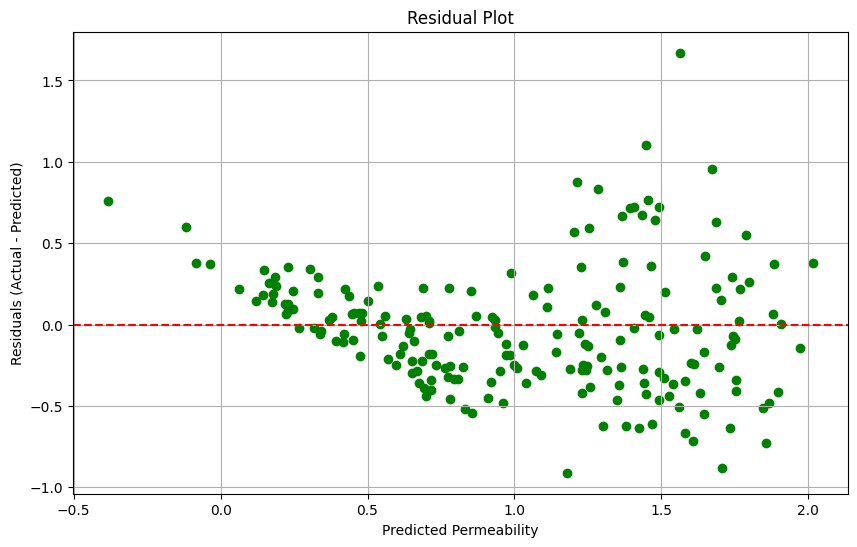

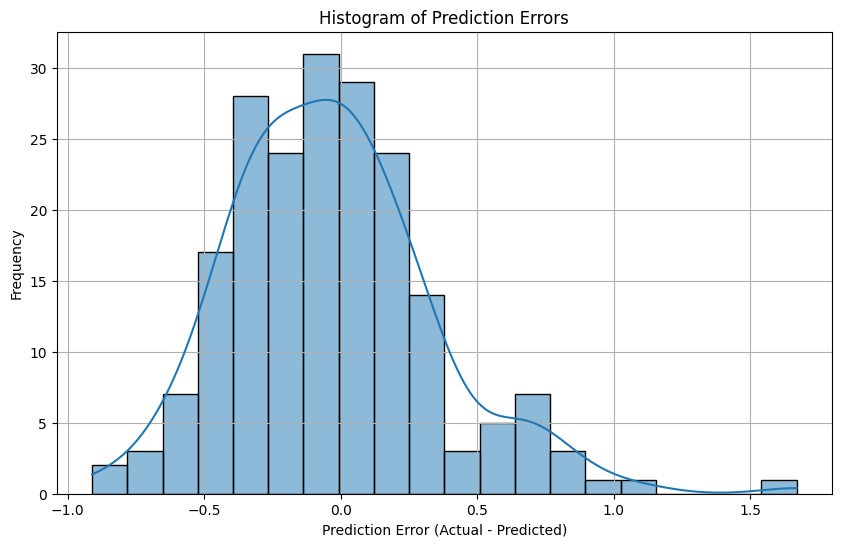

In [ ]:
# LINEAR REGRESSION

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)
n_samples = 100

X_train, X_test, y_train, y_test = train_test_split(X_final, Y, test_size=0.2, random_state=42)

print(f"Check data:\nMax embedding value (train): {np.max(X_train)}")
print(f"Min embedding value (train): {np.min(X_train)}\n")

print(f"Check data:\nMax permeability value (train): {np.max(y_train)}")
print(f"Min permeability value (train): {np.min(y_train)}\n")

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")

# Residual Plot
plt.figure(figsize=(10, 6))
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Permeability')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

# Histogram of Prediction Errors
plt.figure(figsize=(10, 6))
errors = y_test - y_pred
sns.histplot(errors, bins=20, kde=True)
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Histogram of Prediction Errors')
plt.grid(True)
plt.show()

In [ ]:
# NEURAL NETWORK

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

n_samples = len(X_final)

X_tensor = torch.tensor(X_final, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32).unsqueeze(1) # Reshape for single output

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X_tensor, Y_tensor, test_size=0.25, random_state=42)
print(f"Check data (Neural Network):\nMax embedding value (train): {torch.max(X_train_nn)}")
print(f"Min embedding value (train): {torch.min(X_train_nn)}\n")

print(f"Check data (Neural Network):\nMax permeability value (train): {torch.max(y_train_nn)}")
print(f"Min permeability value (train): {torch.min(y_train_nn)}\n")

# Define the neural network architecture
class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.dropout1 = nn.Dropout(p=0.3)
        self.fc2 = nn.Linear(64, 64)
        # self.dropout2 = nn.Dropout(p=0.2)
        self.fc3 = nn.Linear(64, 64)
        # self.dropout3 = nn.Dropout(p=0.05)
        self.fc4 = nn.Linear(64, 64)
        # self.dropout4 = nn.Dropout(p=0.2)
        self.fc5 = nn.Linear(64, 64)
        # self.dropout5 = nn.Dropout(p=0.2)
        self.fc6 = nn.Linear(64, 32)
        # self.dropout6 = nn.Dropout(p=0.05)
        self.fc7 = nn.Linear(32, 8)
        self.dropout7 = nn.Dropout(p=0.05)
        self.fc8 = nn.Linear(8, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        x = torch.relu(self.fc4(x))
        # x = self.dropout4(x)
        x = torch.relu(self.fc5(x))
        # x = self.dropout5(x)
        x = torch.relu(self.fc6(x))
        # x = self.dropout6(x)
        x = self.fc7(x)
        x = self.dropout7(x)
        x = self.fc8(x)
        return x

# Instantiate the model
input_dim = X_train_nn.shape[1]
nn_model = SimpleNN(input_dim)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(nn_model.parameters(), lr=0.01, weight_decay=0.005)

# Create DataLoader for batching
train_dataset_nn = TensorDataset(X_train_nn, y_train_nn)
train_loader_nn = DataLoader(train_dataset_nn, batch_size=32, shuffle=True)

# Training loop
epochs = 200
train_losses = []
test_losses = []

def train():
  for epoch in range(epochs):
      nn_model.train()
      epoch_loss = 0
      for inputs, targets in train_loader_nn:
          optimizer.zero_grad()
          outputs = nn_model(inputs)
          loss = criterion(outputs, targets)
          loss.backward()
          optimizer.step()
          epoch_loss += loss.item() * inputs.size(0)
      train_loss = epoch_loss / len(train_dataset_nn)
      train_losses.append(train_loss)

      nn_model.eval()
      with torch.no_grad():
          test_outputs = nn_model(X_test_nn)
          test_loss = criterion(test_outputs, y_test_nn).item()
          test_losses.append(test_loss)

      if (epoch + 1) % 10 == 0:
          print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')

  # Make predictions on the test set
  nn_model.eval()
  with torch.no_grad():
      y_pred_nn = nn_model(X_test_nn).numpy()
      y_test_nn_np = y_test_nn.numpy()

  # Evaluate the neural network
  r2_nn = r2_score(y_test_nn_np, y_pred_nn)
  mae_nn = mean_absolute_error(y_test_nn_np, y_pred_nn)
  return r2_nn, mae_nn, train_losses, test_losses, y_test_nn_np, y_pred_nn

r2_nn = -1_000 # low number
while r2_nn < 0.7:
  r2_nn, mae_nn, train_losses, test_losses, y_test_nn_np, y_pred_nn = train()

print(f"\nR² (Neural Network): {r2_nn:.4f}")
print(f"MAE (Neural Network): {mae_nn:.4f}")

# Loss Curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', color='b')
plt.plot(test_losses, label='Test Loss', color='o')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Test Loss Curves (Neural MT)')
plt.legend()
plt.grid(True)
plt.show()

# Residual Plot (Neural Network)
plt.figure(figsize=(10, 6))
residuals_nn = y_test_nn_np - y_pred_nn
plt.scatter(y_pred_nn, residuals_nn, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Permeability (Neural Network)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot (Neural Network)')
plt.grid(True)
plt.show()

# Histogram of Prediction Errors (Neural Network)
plt.figure(figsize=(10, 6))
errors_nn = y_test_nn_np - y_pred_nn
sns.histplot(errors_nn, bins=20, kde=True, color='purple')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Histogram of Prediction Errors (Neural Network)')
plt.grid(True)
plt.show()


--- Random Forest Regression ---
Check data (Random Forest Regression):
Max embedding value (train): 0.4569843113422394
Min embedding value (train): -0.465987890958786

Check data (Random Forest Regression):
Max permeability value (train): 4.203193370279175
Min permeability value (train): 0.24556475340649675

R² (Random Forest Regression): 0.5455
MAE (Random Forest Regression): 0.3114


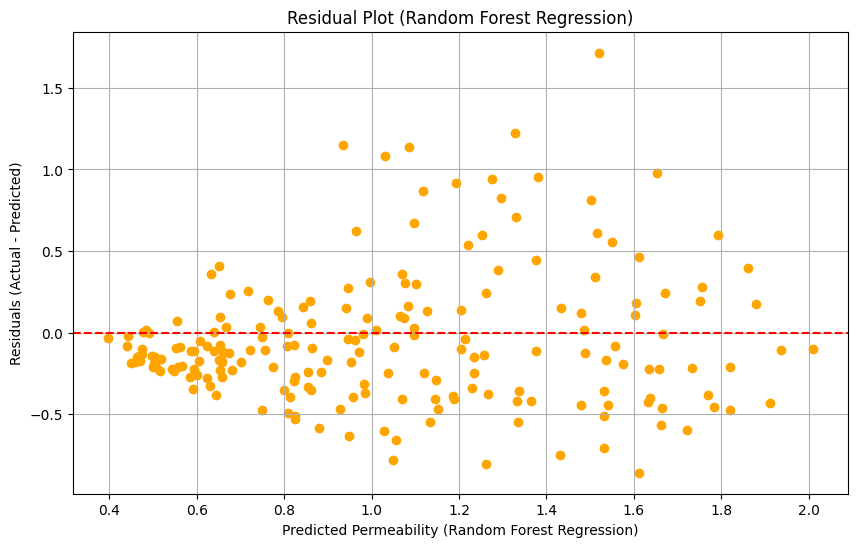

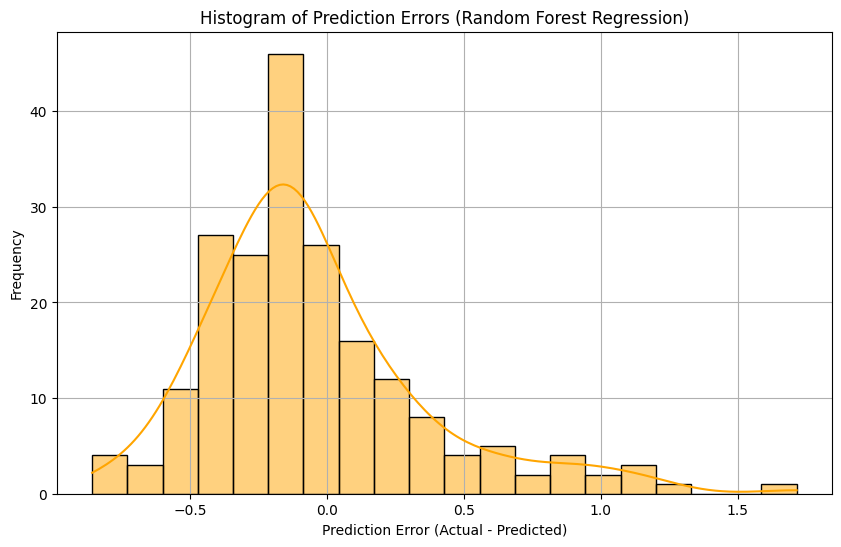

In [ ]:
# RANDOM FOREST REGRESSION

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
n_samples = len(X_final)

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_final, Y, test_size=0.2, random_state=42)

print("\n--- Random Forest Regression ---")
print(f"Check data (Random Forest Regression):\nMax embedding value (train): {np.max(X_train_rf)}")
print(f"Min embedding value (train): {np.min(X_train_rf)}\n")

print(f"Check data (Random Forest Regression):\nMax permeability value (train): {np.max(y_train_rf)}")
print(f"Min permeability value (train): {np.min(y_train_rf)}\n")

# Create and train the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)  # You can adjust hyperparameters
rf_model.fit(X_train_rf, y_train_rf)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_rf)

# Evaluate the model
r2_rf = r2_score(y_test_rf, y_pred_rf)
mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)

print(f"R² (Random Forest Regression): {r2_rf:.4f}")
print(f"MAE (Random Forest Regression): {mae_rf:.4f}")

# Residual Plot (Random Forest Regression)
plt.figure(figsize=(10, 6))
residuals_rf = y_test_rf - y_pred_rf
plt.scatter(y_pred_rf, residuals_rf, color='orange')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Permeability (Random Forest Regression)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot (Random Forest Regression)')
plt.grid(True)
plt.show()

# Histogram of Prediction Errors (Random Forest Regression)
plt.figure(figsize=(10, 6))
errors_rf = y_test_rf - y_pred_rf
sns.histplot(errors_rf, bins=20, kde=True, color='orange')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Histogram of Prediction Errors (Random Forest Regression)')
plt.grid(True)
plt.show()

##METHOD TWO: GRAPH CONVOLUTIONS

In [ ]:
len(X)

1000

In [ ]:
print("Collecting data")
import networkx
from torch_geometric.utils import from_networkx
geometric_data_list = []
for i in range(len(X)):
    raw_network = op.io.network_from_porespy(X[i]["network"])
    nx_graph = op.io.network_to_networkx(raw_network)

    data = from_networkx(nx_graph)
    data.y = torch.tensor(Y[i]).float()
    geometric_data_list.append(data) # for PyTorch Geometric models

train_data = geometric_data_list[:800]
test_data = geometric_data_list[800:]

/usr/local/lib/python3.11/dist-packages/torch_geometric/utils/convert.py:278: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  data_dict[key] = torch.as_tensor(value)


In [ ]:
print(nx_graph.nodes(data=True))

[(0, {'coordination_number': np.float64(10.0), 'coords': [np.float64(10.903700756068444), np.float64(10.119379228014326), np.float64(8.546358933545562)], 'diameter': np.float64(16.868039995589637), 'equivalent_diameter': np.float64(16.868039995589637), 'extended_diameter': np.float64(15.36229133605957), 'geometric_centroid': [np.float64(10.903700756068444), np.float64(10.119379228014326), np.float64(8.546358933545562)], 'global_peak': [np.float64(2.0), np.float64(10.0), np.float64(5.0)], 'inscribed_diameter': np.float64(9.380831718444824), 'local_peak': [np.float64(8.0), np.float64(11.0), np.float64(8.0)], 'phase': np.int64(1), 'region_label': np.int64(1), 'region_volume': np.float64(2513.0), 'surface_area': np.float64(650.0), 'volume': np.float64(2513.0), 'all': np.True_, 'boundary': np.False_, 'xmax': np.False_, 'xmin': np.False_, 'ymax': np.False_, 'ymin': np.False_, 'zmax': np.False_, 'zmin': np.False_}), (1, {'coordination_number': np.float64(4.0), 'coords': [np.float64(3.97959183

In [ ]:
print("Collecting data")
import networkx
from torch_geometric.utils import from_networkx
import torch

geometric_data_list = []
for i in range(len(X)):
    raw_network = op.io.network_from_porespy(X[i]["network"])
    nx_graph = op.io.network_to_networkx(raw_network)

    # Specify which node attribute(s) to use as features
    # You might want to use 'coords' or a combination of relevant attributes
    feature_attributes = ['coords']  # Use the 'coords' attribute as node features
    data = from_networkx(nx_graph, group_node_attrs=feature_attributes)

    # It's still good practice to check if data.x is None, although it's less likely now
    if data.x is None:
        num_nodes = data.num_nodes
        data.x = torch.ones((num_nodes, len(feature_attributes[0])), dtype=torch.float)

    data.y = torch.tensor(Y[i]).float()
    geometric_data_list.append(data) # for PyTorch Geometric models

train_data = geometric_data_list[:800]
test_data = geometric_data_list[800:]

In [ ]:
import torch
import torch_geometric
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data, DataLoader
import random
import networkx as nx

from torch.nn import Linear, BatchNorm1d, Dropout

class GCNRegressor(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(GCNRegressor, self).__init__()
        self.conv1 = GCNConv(3, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 1)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)

        # Pooling to get graph-level representation
        x = global_mean_pool(x, batch)
        return self.lin(x)

# ---- Training setup ---- #
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16)

model = GCNRegressor(hidden_channels=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = torch.nn.MSELoss()

# ---- Training loop ---- #
for epoch in range(100):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = loss_fn(out, batch.y.unsqueeze(1)) # Ensure target has the correct shape
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch:03d}, Loss: {total_loss / len(train_loader):.4f}")

# ---- Evaluation ---- #
model.eval()
preds = []
labels = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.batch)
        preds.append(out.cpu())
        labels.append(batch.y.cpu().unsqueeze(1))

preds = torch.cat(preds)
labels = torch.cat(labels)

# Calculate metrics
mse = F.mse_loss(preds, labels).item()
mae = F.l1_loss(preds, labels).item()
r2 = 1 - mse / torch.var(labels, unbiased=False).item()

print(f"Test MAE: {mae:.4f}, MSE: {mse:.4f}, R²: {r2:.4f}")

preds_np = preds.cpu().numpy().flatten()
labels_np = labels.cpu().numpy().flatten()

# Residual Plot (Convolutions)
plt.figure(figsize=(10, 6))
residuals = labels_np - preds_np  # Calculate residuals
plt.scatter(preds_np, residuals, color='skyblue')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Permeability (GCN Regression)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot (GCN Regression)')
plt.grid(True)
plt.show()

# Histogram of Prediction Errors (Convolutions)
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=20, kde=True, color='skyblue')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Histogram of Prediction Errors (GCN Regression)')
plt.grid(True)
plt.show()

RuntimeError: expected m1 and m2 to have the same dtype, but got: double != float

In [ ]:
import torch
import torch_geometric
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.utils import from_networkx
from torch_geometric.data import Data, DataLoader
import random
import networkx as nx  # Import NetworkX

# Assume you have a list of NetworkX graphs called 'networkx_graphs'
# and corresponding labels 'graph_labels'

# ---- Define a simple GCN model for graph regression ---- #
from torch.nn import Linear

class GCNRegressor(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(GCNRegressor, self).__init__()
        self.conv1 = GCNConv(1, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 1)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)

        # Pooling to get graph-level representation
        x = global_mean_pool(x, batch)
        return self.lin(x)

# ---- Training setup ---- #
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16)

model = GCNRegressor(hidden_channels=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = torch.nn.MSELoss()

# ---- Training loop ---- #
for epoch in range(1, 101):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = loss_fn(out, batch.y.unsqueeze(1)) # Ensure target has the correct shape
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch:03d}, Loss: {total_loss / len(train_loader):.4f}")

# ---- Evaluation ---- #
model.eval()
preds = []
labels = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.batch)
        preds.append(out.cpu())
        labels.append(batch.y.cpu().unsqueeze(1)) # Ensure target has the correct shape

preds = torch.cat(preds)
labels = torch.cat(labels)

# Calculate metrics
mse = F.mse_loss(preds, labels).item()
mae = F.l1_loss(preds, labels).item()
r2 = 1 - mse / torch.var(labels, unbiased=False).item()

print(f"Test MAE: {mae:.4f}, MSE: {mse:.4f}, R²: {r2:.4f}")

/usr/local/lib/python3.11/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


AttributeError: 'NoneType' object has no attribute 'size'